<a href="https://colab.research.google.com/github/vanshika704/celebal/blob/main/week3_vanshika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# import data
data = pd.read_csv("/content/Country-data.csv")
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [8]:
# data cleaning
data.isnull().sum()
data.columns
data.duplicated().sum()

np.int64(0)

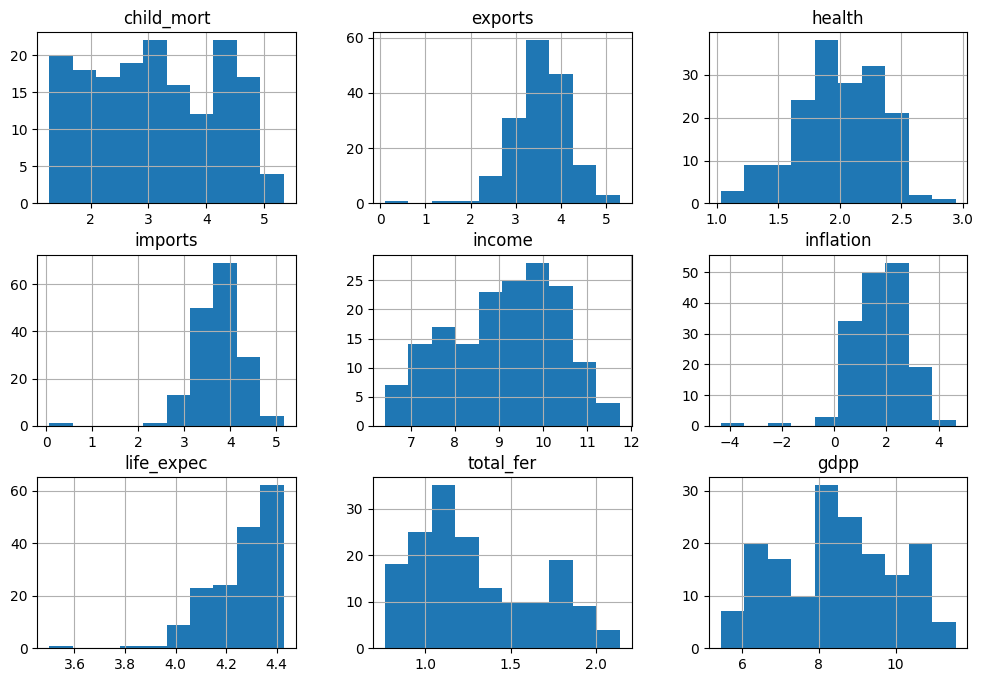

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


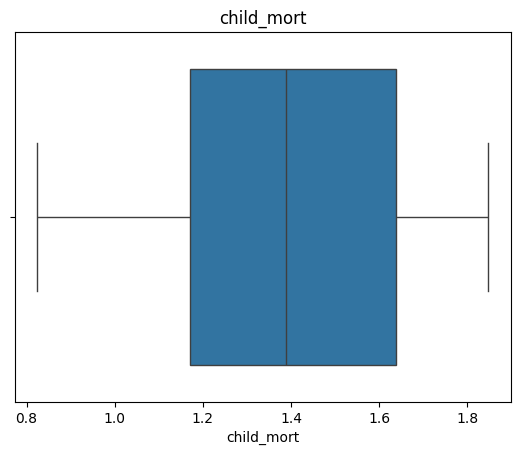

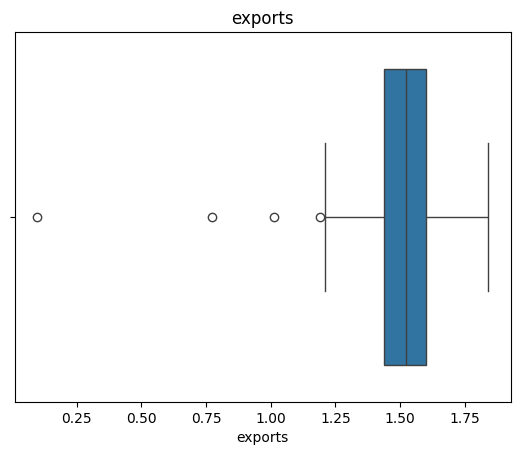

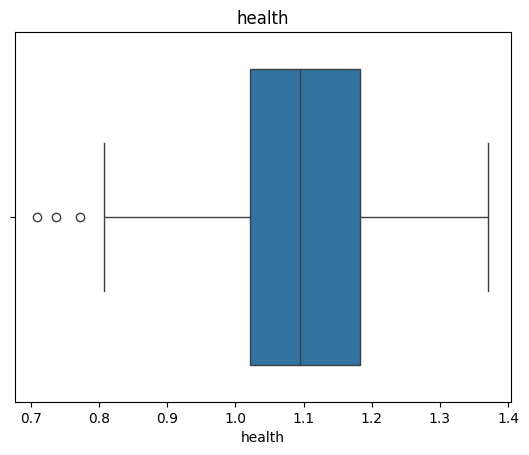

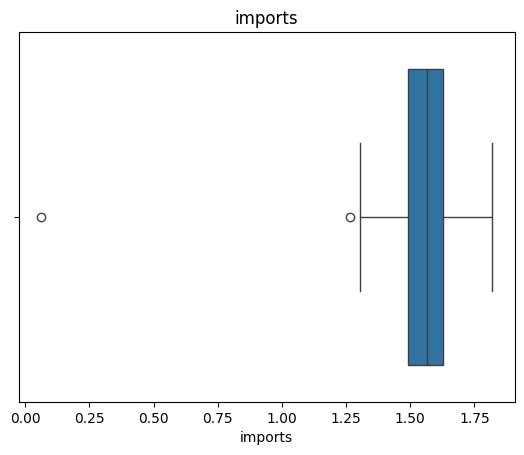

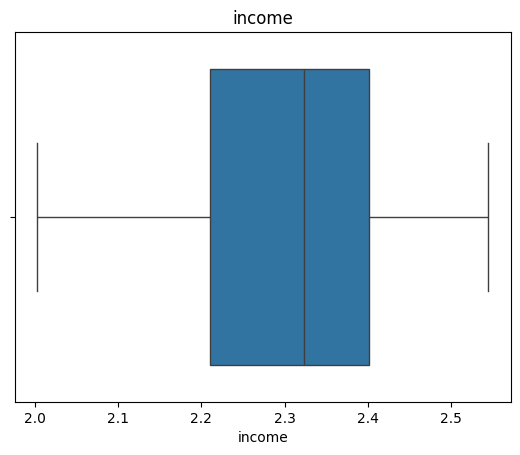

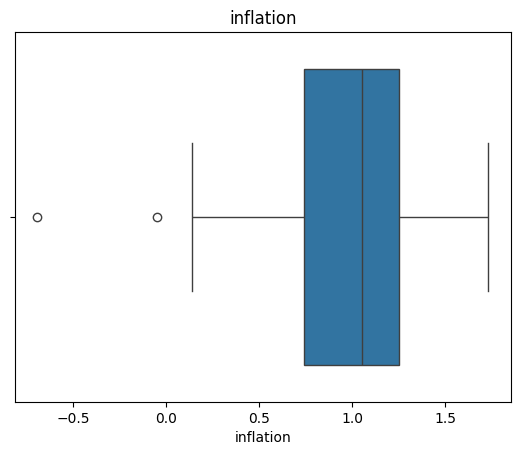

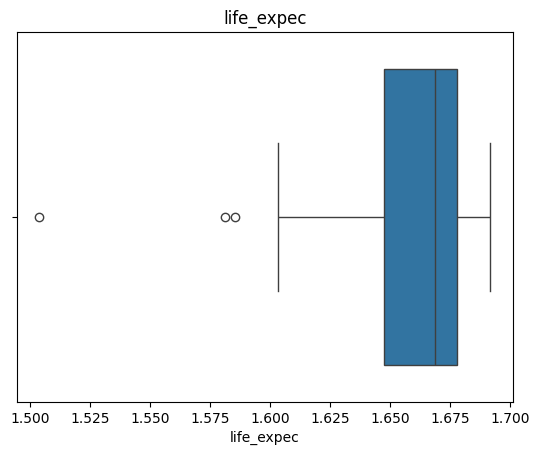

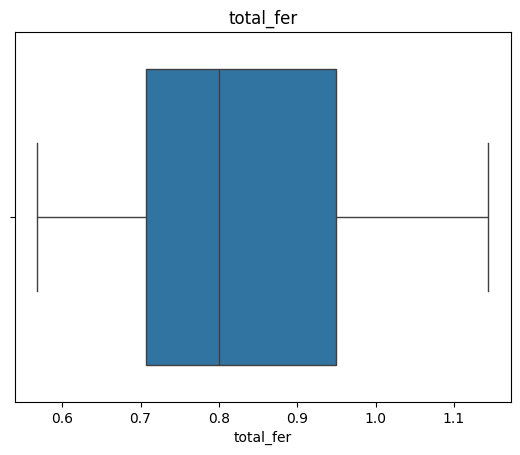

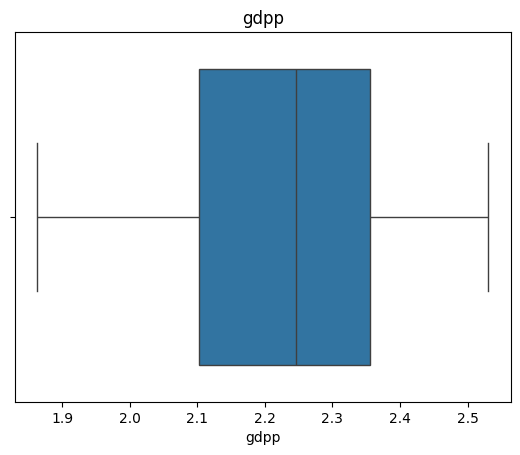

In [13]:
# eda
data.describe()
data.hist(figsize=(12,8))
plt.show()

for col in data.select_dtypes(include=np.number):
    data[col] = np.log1p(data[col])
for col in data.select_dtypes(include=np.number):
    plt.figure()
    sns.boxplot(x=data[col])
    plt.title(col)


In [19]:
# feature engineering
data['health_per_gdp'] = data['health'] / data['gdpp']
data['overall_development'] = (
    data['income'] + data['health'] + data['gdpp']
)
data['income_group'] = pd.cut(
    data['income'],
    bins=3,
    labels=['low','medium','high']
)
data['income_health'] = data['income'] * data['health']

In [28]:
# encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# One Hot Encoding
data_encoded = pd.get_dummies(data, columns=['income_group'])
data_numeric = data_encoded.select_dtypes(include=np.number)

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Apply scaling
scaled_data = scaler.fit_transform(data_numeric)

# Convert back to DataFrame
scaled_data = pd.DataFrame(scaled_data, columns=data_numeric.columns)

['gdpp', 'overall_development', 'income_health']


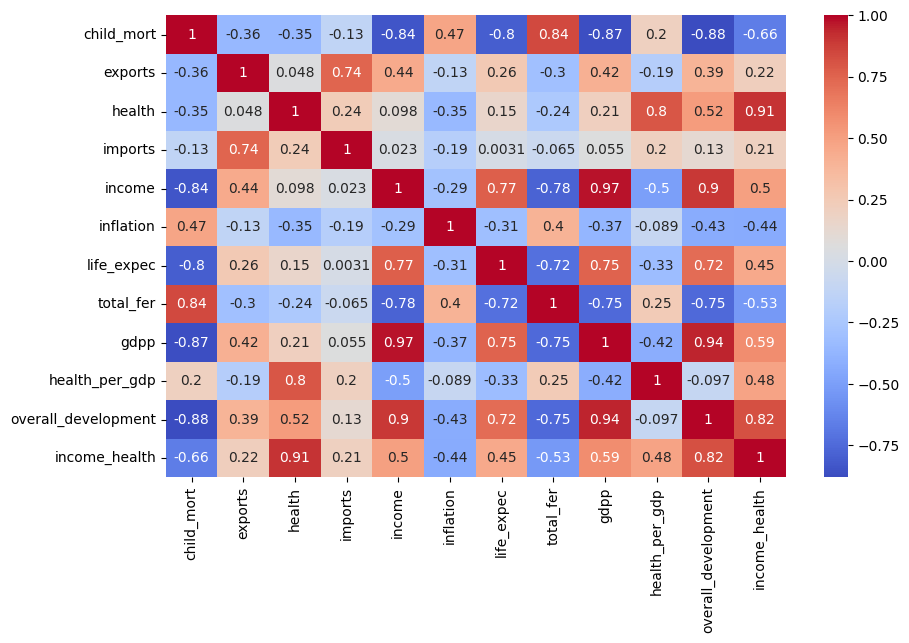

In [38]:
corr = data_numeric.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
import numpy as np

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
print(to_drop)

data_reduced = data_numeric.drop(columns=to_drop)

In [46]:
data_numeric.isnull().sum()
data_numeric['inflation'] = data_numeric['inflation'].fillna(data_numeric['inflation'].median())
data_numeric.isnull().sum()
corr = data_numeric.corr()
import numpy as np

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
print(to_drop)
data_reduced = data_numeric.drop(columns=to_drop)

['gdpp', 'overall_development', 'income_health']


In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_reduced)

In [48]:
# k means
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

In [49]:
data_reduced['cluster'] = clusters

In [50]:
data_reduced.groupby('cluster').mean()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,health_per_gdp
cluster,,,,,,,,,
0,1.667995,1.422152,1.097954,1.559494,2.159279,1.088445,1.630695,1.000452,0.533823
1,1.436709,1.512190,0.967616,1.497948,2.340591,1.184363,1.664282,0.816802,0.429347
2,1.122530,1.556913,1.171695,1.577160,2.393598,0.742278,1.679509,0.697361,0.497000


In [51]:
data_numeric.isnull().sum()

,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0
health_per_gdp,0


In [57]:
data_reduced['cluster'] = clusters

In [58]:
data_reduced['cluster'].value_counts()
data_reduced.groupby('cluster').mean()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,health_per_gdp
cluster,,,,,,,,,
0,1.667995,1.422152,1.097954,1.559494,2.159279,1.088445,1.630695,1.000452,0.533823
1,1.436709,1.512190,0.967616,1.497948,2.340591,1.184363,1.664282,0.816802,0.429347
2,1.122530,1.556913,1.171695,1.577160,2.393598,0.742278,1.679509,0.697361,0.497000


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,health_per_gdp,cluster
0,1.707119,1.223156,1.147223,1.574114,2.126398,1.207659,1.618706,1.071535,0.576429,0
1,1.352711,1.474144,1.105769,1.590049,2.322723,0.994336,1.676665,0.680345,0.495462,2
2,1.468534,1.541965,0.971866,1.499212,2.348042,1.345232,1.677149,0.857987,0.433667,1
3,1.755699,1.638586,0.853595,1.564841,2.270359,1.423767,1.631691,1.088060,0.385220,1
4,1.231044,1.576802,1.081868,1.627804,2.384856,0.637633,1.677870,0.761288,0.461805,2


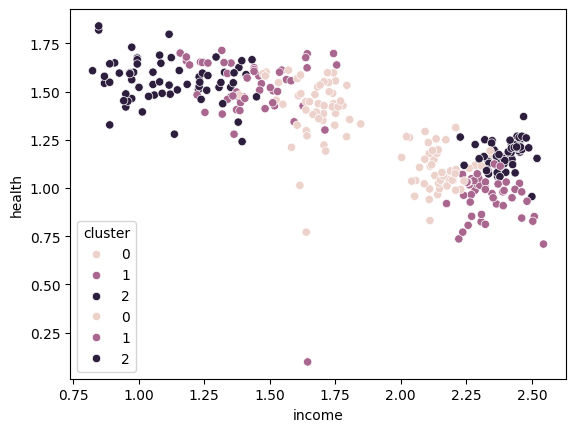

In [62]:
sns.scatterplot(
    x=data_reduced['income'],
    y=data_reduced['health'],   # or any existing column
    hue=data_reduced['cluster']
)


sns.scatterplot(
    x=data_reduced.iloc[:, 0],
    y=data_reduced.iloc[:, 1],
    hue=data_reduced['cluster']
)


data_reduced.head()

In [66]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters_db = dbscan.fit_predict(scaled_data)

data_reduced['dbscan_cluster'] = clusters_db

In [67]:
data_reduced['dbscan_cluster'].value_counts()

,count
dbscan_cluster,
-1,167


In [69]:
print(data_reduced.groupby('cluster').mean())

         child_mort   exports    health   imports    income  inflation  \
cluster                                                                  
0          1.667995  1.422152  1.097954  1.559494  2.159279   1.088445   
1          1.436709  1.512190  0.967616  1.497948  2.340591   1.184363   
2          1.122530  1.556913  1.171695  1.577160  2.393598   0.742278   

         life_expec  total_fer  health_per_gdp  dbscan_cluster  
cluster                                                         
0          1.630695   1.000452        0.533823            -1.0  
1          1.664282   0.816802        0.429347            -1.0  
2          1.679509   0.697361        0.497000            -1.0  


In [70]:
data_reduced['target'] = data_reduced['cluster']

In [71]:
X = data_reduced.drop(['cluster', 'dbscan_cluster', 'target'], axis=1)
y = data_reduced['target']

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [73]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [74]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8235294117647058
              precision    recall  f1-score   support

           0       0.73      1.00      0.84         8
           1       1.00      0.58      0.74        12
           2       0.81      0.93      0.87        14

    accuracy                           0.82        34
   macro avg       0.85      0.84      0.82        34
weighted avg       0.86      0.82      0.82        34



In [75]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.8235294117647058


In [76]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [77]:
from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8235294117647058


In [78]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [79]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9117647058823529


In [80]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

,0
total_fer,0.208497
health,0.171534
child_mort,0.164843
income,0.133614
health_per_gdp,0.130539
life_expec,0.091008
inflation,0.055616
exports,0.026174
imports,0.018175


In [81]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

,0
total_fer,0.208497
health,0.171534
child_mort,0.164843
income,0.133614
health_per_gdp,0.130539
life_expec,0.091008
inflation,0.055616
exports,0.026174
imports,0.018175


In [84]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

from sklearn.metrics import accuracy_score

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Logistic:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("XGBoost:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8823529411764706
Logistic: 0.8235294117647058
Decision Tree: 0.8235294117647058
Random Forest: 0.9117647058823529
XGBoost: 0.8823529411764706


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:37:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
